In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def rlsSnrInitParams(
    snr_db: float,
    sigma_u2: float = 1.0,
    lam: float = 0.99,
    delta_high_snr: float = 100.0,
    delta_mid_snr: float = 1.0,
    delta_low_snr: float = 0.01,
) -> dict:
  """
  Intuitive SNR-based initialization for a Diniz-style RLS class.

  Your class uses:
      S_D(-1) = delta * I

  Intuition:
    high SNR -> trust data early  -> larger Diniz delta
    low SNR  -> trust data less   -> smaller Diniz delta

  lambda is kept fixed here so we isolate initialization effect.
  """
  if sigma_u2 <= 0.0:
    raise ValueError("sigma_u2 must be > 0")
  if not (0.0 < lam <= 1.0):
    raise ValueError("lam must satisfy 0 < lam <= 1")
  if not (delta_high_snr > 0.0 and delta_mid_snr > 0.0 and delta_low_snr > 0.0):
    raise ValueError("all deltas must be > 0")

  if snr_db >= 30.0:
    delta = delta_high_snr
    mode = "high_snr"
  elif snr_db <= -10.0:
    delta = delta_low_snr
    mode = "low_snr"
  elif snr_db >= 10.0:
    t = (snr_db - 10.0) / 20.0
    delta = delta_mid_snr + t * (delta_high_snr - delta_mid_snr)
    mode = "mid_to_high_snr"
  else:
    t = (snr_db + 10.0) / 20.0
    delta = delta_low_snr + t * (delta_mid_snr - delta_low_snr)
    mode = "low_to_mid_snr"

  effective_memory = 1.0 / (1.0 - lam) if lam < 1.0 else float("inf")

  return dict(
    snr_db=float(snr_db),
    sigma_u2=float(sigma_u2),
    lambda_value=float(lam),
    delta=float(delta),
    effective_memory=float(effective_memory),
    mode=mode,
  )


def computeAr2NoiseVariance(a1: float, a2: float, target_var: float = 1.0) -> float:
  """
  Compute sigma_v^2 so that
      u(n) = -a1*u(n-1) - a2*u(n-2) + v(n)
  has variance target_var.
  """
  phi1 = -a1
  phi2 = -a2

  r0 = target_var
  r1 = phi1 * r0 / (1.0 - phi2)
  r2 = phi1 * r1 + phi2 * r0

  sigma_v2 = r0 - phi1 * r1 - phi2 * r2
  return float(np.real_if_close(sigma_v2))


def generateAr2Clean(
    n_samp: int,
    a1: float,
    a2: float,
    sigma_v2: float,
    rng: np.random.Generator,
) -> np.ndarray:
  u = np.zeros(n_samp, dtype=np.float64)
  v = rng.normal(0.0, np.sqrt(sigma_v2), size=n_samp)

  for n_idx in range(2, n_samp):
    u[n_idx] = -a1 * u[n_idx - 1] - a2 * u[n_idx - 2] + v[n_idx]

  return u


def addNoiseAtSnr(
    x_clean: np.ndarray,
    snr_db: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, float]:
  sig_power = np.mean(np.abs(x_clean) ** 2)
  noise_power = sig_power / (10.0 ** (snr_db / 10.0))
  noise = rng.normal(0.0, np.sqrt(noise_power), size=x_clean.shape[0])
  x_noisy = x_clean + noise
  return x_noisy, float(noise_power)


def runOneSnrCase(
    rls_cls,
    snr_db: float,
    n_samp: int = 300,
    n_runs: int = 100,
    a1: float = 0.1,
    a2: float = -0.8,
    lam: float = 0.99,
    seed: int = 1234,
):
  """
  AR(2) one-step prediction with noisy observation.
  We use the same lambda for all SNRs and let only delta vary with SNR.

  Predictor target:
      d(n) = observed_u(n)
      x(n) = observed_u(n-1)

  Because your class internally builds a 2-tap regressor from x-history,
  filter_order=1 gives a 2-tap predictor.
  """
  rng = np.random.default_rng(seed)

  sigma_v2 = computeAr2NoiseVariance(a1, a2, target_var=1.0)
  w0 = np.array([-a1, -a2], dtype=np.float64)

  # estimate sigma_u^2 from clean realization for config
  u_ref = generateAr2Clean(n_samp, a1, a2, sigma_v2, rng)
  sigma_u2 = float(np.mean(u_ref ** 2))

  cfg = rlsSnrInitParams(
    snr_db=snr_db,
    sigma_u2=sigma_u2,
    lam=lam,
  )

  n_eff = n_samp - 1
  mse_avg = np.zeros(n_eff, dtype=np.float64)
  werr_avg = np.zeros(n_eff + 1, dtype=np.float64)
  w_mean_final = np.zeros(2, dtype=np.float64)

  for run_idx in range(n_runs):
    u_clean = generateAr2Clean(n_samp, a1, a2, sigma_v2, rng)
    u_obs, noise_power = addNoiseAtSnr(u_clean, snr_db, rng)

    # external shift: unchanged class becomes one-step predictor
    x = u_obs[:-1]
    d = u_obs[1:]

    rls = rls_cls(
      filter_order=1,
      lam=cfg["lambda_value"],
      delta=cfg["delta"],
      dtype=np.complex128,
    )

    _, e_hist, w_hist = rls(x, d, train=True)

    e_hist = np.real(e_hist)
    w_hist = np.real(w_hist)

    mse_avg += e_hist ** 2
    werr = np.sum((w_hist - w0[None, :]) ** 2, axis=1)
    werr_avg += werr
    w_mean_final += w_hist[-1]

  mse_avg /= n_runs
  werr_avg /= n_runs
  w_mean_final /= n_runs

  return dict(
    snr_db=float(snr_db),
    cfg=cfg,
    sigma_v2=float(sigma_v2),
    mse_avg=mse_avg,
    werr_avg=werr_avg,
    w0=w0,
    w_mean_final=w_mean_final,
  )


def demoRlsSnrInitConvergence(
    rls_cls,
    snr_list=(30.0, 10.0, -10.0),
    n_samp: int = 300,
    n_runs: int = 100,
    a1: float = 0.1,
    a2: float = -0.8,
    lam: float = 0.99,
):
  results = []

  for idx, snr_db in enumerate(snr_list):
    res = runOneSnrCase(
      rls_cls=rls_cls,
      snr_db=snr_db,
      n_samp=n_samp,
      n_runs=n_runs,
      a1=a1,
      a2=a2,
      lam=lam,
      seed=1000 + idx,
    )
    results.append(res)

  # ---------------------------
  # print summary
  # ---------------------------
  print("RLS SNR-based initialization demo")
  print("=" * 96)
  print("SNR(dB) | mode            | lambda   | delta        | N_eff   | final w_mean")
  print("-" * 96)
  for res in results:
    cfg = res["cfg"]
    print(
      f"{res['snr_db']:>7.1f} | "
      f"{cfg['mode']:<15s} | "
      f"{cfg['lambda_value']:>8.5f} | "
      f"{cfg['delta']:>12.4e} | "
      f"{cfg['effective_memory']:>7.1f} | "
      f"{res['w_mean_final']}"
    )

  # ---------------------------
  # plot prediction MSE
  # ---------------------------
  plt.figure(figsize=(10, 6))
  for res in results:
    plt.plot(
      10.0 * np.log10(res["mse_avg"] + 1e-12),
      label=(
        f"SNR={res['snr_db']:.0f} dB, "
        f"δ={res['cfg']['delta']:.2e}"
      ),
    )
  plt.title("Ensemble-Average Prediction MSE vs SNR")
  plt.xlabel("Iteration")
  plt.ylabel("Prediction MSE (dB)")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  # ---------------------------
  # plot weight-error norm
  # this is the key 'converges faster' proof
  # ---------------------------
  plt.figure(figsize=(10, 6))
  for res in results:
    plt.plot(
      10.0 * np.log10(res["werr_avg"] + 1e-16),
      label=(
        f"SNR={res['snr_db']:.0f} dB, "
        f"δ={res['cfg']['delta']:.2e}"
      ),
    )
  plt.title("Ensemble-Average Weight-Error Norm vs SNR")
  plt.xlabel("Iteration")
  plt.ylabel(r"$\|\hat w(n)-w_0\|^2$ (dB)")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  # ---------------------------
  # bar plot final mean weights
  # ---------------------------
  x_pos = np.arange(2)
  width = 0.22
  w0 = results[0]["w0"]

  plt.figure(figsize=(10, 6))
  for idx, res in enumerate(results):
    plt.bar(
      x_pos + (idx - 1) * width,
      res["w_mean_final"],
      width=width,
      label=f"SNR={res['snr_db']:.0f} dB"
    )
  plt.plot(x_pos, w0, "ko--", label="true $w_0$")
  plt.xticks(x_pos, [r"$w_1$", r"$w_2$"])
  plt.title("Final Ensemble-Average Weights")
  plt.ylabel("Coefficient Value")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

  return results

RLS SNR-based initialization demo
SNR(dB) | mode            | lambda   | delta        | N_eff   | final w_mean
------------------------------------------------------------------------------------------------
   30.0 | high_snr        |  0.99000 |   1.0000e+02 |   100.0 | [-0.10117785  0.77962336]
   10.0 | mid_to_high_snr |  0.99000 |   1.0000e+00 |   100.0 | [-0.1422935   0.68133958]
  -10.0 | low_snr         |  0.99000 |   1.0000e-02 |   100.0 | [-0.03812458  0.05603998]


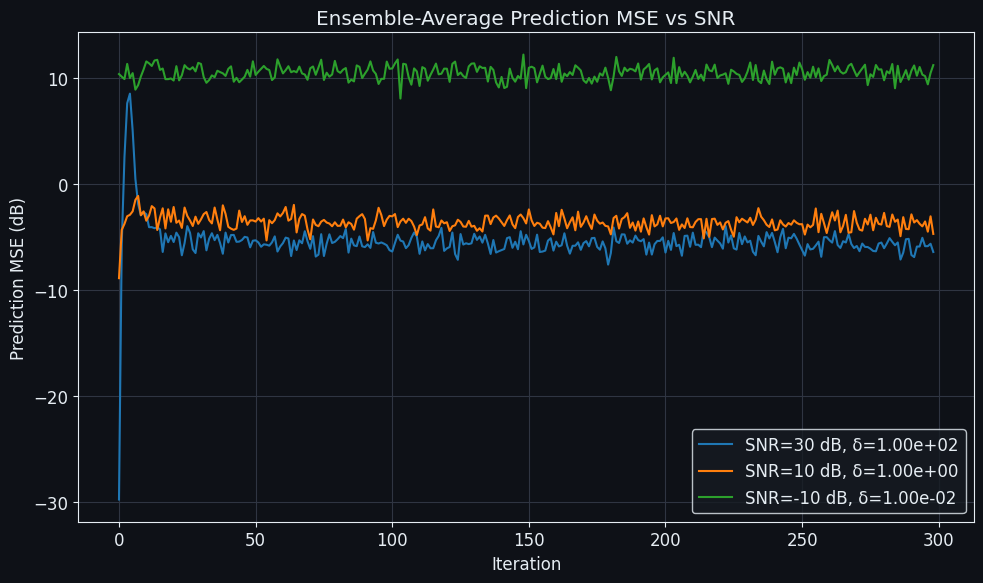

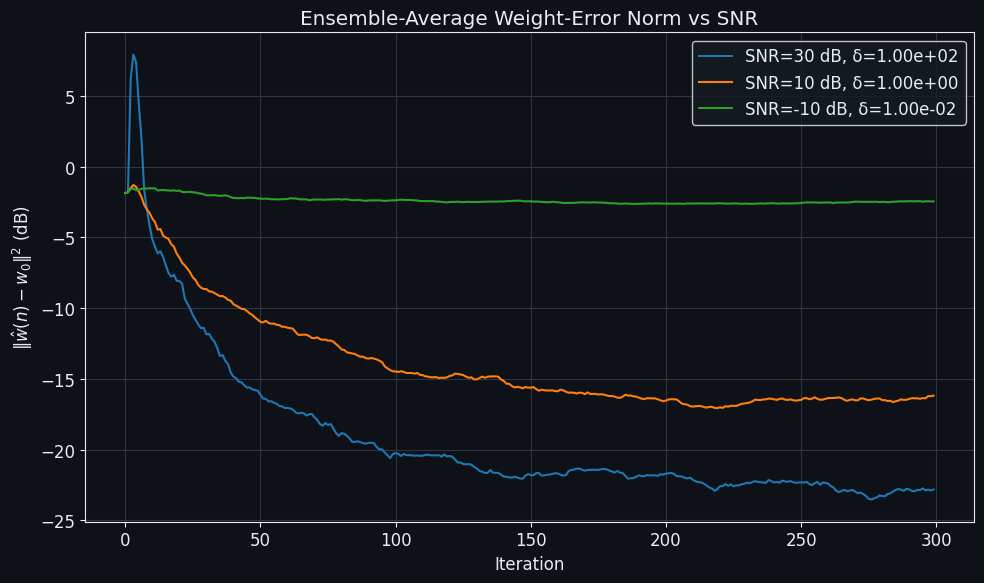

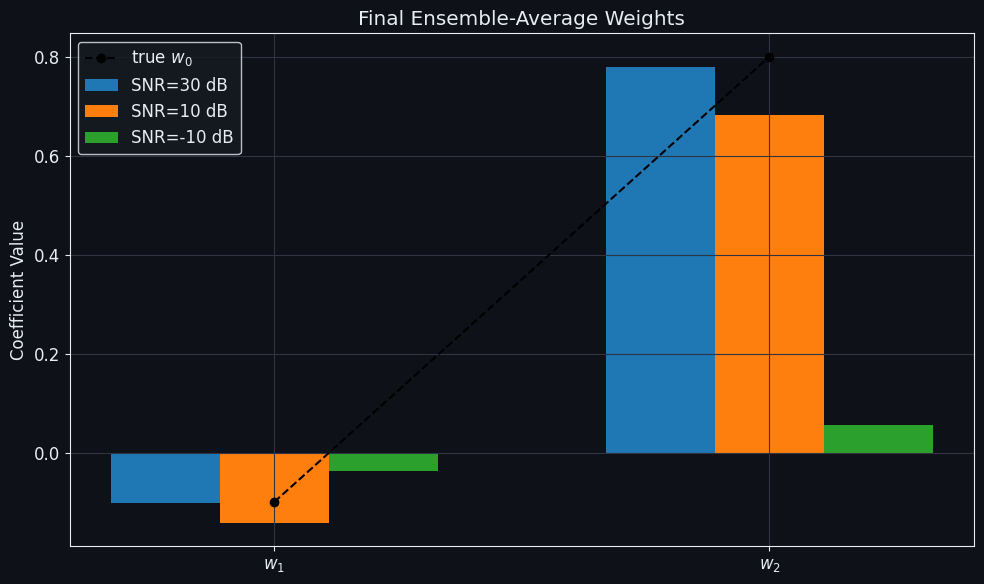

In [3]:
results = demoRlsSnrInitConvergence(
  rls_cls=adspfilter.RLS,
  snr_list=(30.0, 10.0, -10.0),
  n_samp=300,
  n_runs=100,
  a1=0.1,
  a2=-0.8,
  lam=0.99,
)